### import Dependencies

In [1]:
import openai
import pandas as pd
from qdrant_client import QdrantClient, models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier,PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Literal, Annotated, List, Any
from operator import add
import random
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage
import instructor
from langsmith import traceable, get_current_run_tree
from openai import OpenAI
import os


c:\Users\jaysi\Desktop\Desktop\Ai-engineering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
qdrant_client=QdrantClient(url="http://localhost:6333/")

Query Expansion /Rewriting Nodes

In [3]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    question_relevant:bool=False
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10



In [4]:
class QueryExpandResponse(BaseModel):
    query:List[str]

In [5]:
@traceable(
    name="query_expansion",
    run_type="llm"
)
def query_expansion_node(state:State) -> dict:
    print("Heelllo mai hi hun")
    prompt_template = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite the customer's query into distinct statements for semantic search.
    ## Instructions:
    - Expand the customer's query into a list of distinct statements (1 to 5 concise statements)
    - Each statement should capture a separate product or attribute from the query
    - Use natural product description language
    - Do not produce multiple statements that express the same intent

    ## Examples:
    Query: "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
    Statements:
    - tablet for kids
    - watch for adults
    - laptop

    Query: "I need a warm winter jacket for hiking"
    Statements:
    - warm winter jacket
    - hiking outfit for cold weather

    <query>:
    {{query}}
    </query>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=QueryExpandResponse,
        reasoning={"effort":"none"}
    )
    return {
        'expanded_query': response.query
    }


In [6]:
def query_expand_condition_edges(state:State):
    send_messages=[]

    for query in state.expanded_query:
        send_messages.append(
            Send(
                
               "retriever_node", 

                {
                    "query":query,
                    "K":10
                }
            )
        )
    
    return send_messages

In [7]:
def get_embedding(text,model="text-embedding-3-small"):
    response=openai.embeddings.create(
        input=[text],
        model=model
    )
    return response.data[0].embedding
    
def retriever_node(state: dict) -> dict:
    query = state["query"]
    k = state.get("K", 10)
    query_embedding = get_embedding(query)

    result = qdrant_client.query_points(
        collection_name="Amazon-items-collection-02-hybrid-serach",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-model-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k
    )
    print("Ok The Result is",result)
    retrieved_context_ids = []
    retrieved_context = []
    retrieved_context_rating = []

    for point in result.points:
        payload = point.payload or {}
        retrieved_context_ids.append(payload.get("parent_asin"))
        retrieved_context.append(payload.get("description", ""))
        retrieved_context_rating.append(payload.get("average_rating"))

    formatted_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_rating):
        formatted_context += f"-ID: {id} , rating: {rating} ,description:{chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

  


In [8]:
class AggregratorNode(BaseModel):
    answer:str=Field(description="Answer to the question")


In [9]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def aggregator_node(state: State) -> dict:
    preprocessed_context = '\n'.join(state.retrieved_context)

    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.
      
    You will be given a question and a list of context.

    Instructions:
    - Answer the question based on the context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain  detailed information about the product and returned with detailed specification in bullet points.
     
    Context:
    {{preprocessed_context}}

    Question:
    {{question}}
    """
    template = Template(prompt_template)
    prompt = template.render(preprocessed_context=preprocessed_context, question=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=AggregatorResponse,
        reasoning={"effort":"none"}
    )
    return {
        'answer': response.answer
    }

## User Intent Node

In [10]:
class AggregatorResponse(BaseModel):
    answer: str

In [11]:
class IntentRouterResponce(BaseModel):
    question_relevant:bool
    answer:str

In [12]:
def intent_router_node(state:State):
    prompt_template=""" You are part of a shopping assistant that can answer questions about product in stock

    Instruction:
    -You are given a question and you need to classify it into relevant or not relavant.
    -If the question is not relevant ,return False in Field ""question_relavant" and set "answer" to explanation why it is not relevant.
    -If the question is relevant , return True in field "question_relavant" and set "answer" to .
    - You should only answer question the products in stock. If the question is not about the products in stock ,you should ask for clarification
    <Question>
    {{query}}
    </Question>
    -
    """
    template=Template(prompt_template)

    prompt=template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response,raw_response=client.create_with_completion(
        model="gpt-4.1-mini",
        response_model=IntentRouterResponce,
        messages=[
            {
                "role":"system",

                 "content":prompt
            }
        ],
        temperature=0.5,
    )

    return {
        "question_relevant":response.question_relevant,
        "answer":response.answer
    }


In [13]:
def intent_router_conditional_edges(state:State):
    if state.question_relevant:       # fix typo: relavant → relevant
        return "query_expansion_node"
    else: return "end"                  # fix: end → END


In [ ]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node",  retriever_node)  
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node",intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node":"query_expansion_node",
        "end":END
    }
)
workflow.add_conditional_edges("query_expansion_conditional", query_expand_condition_edges)

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

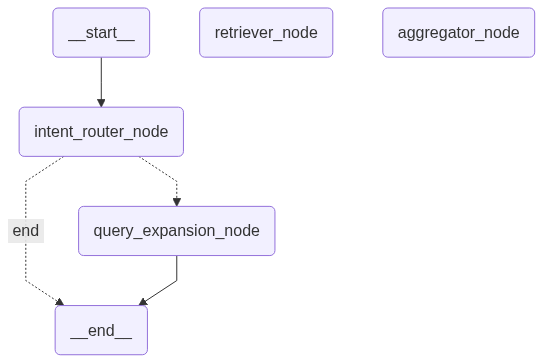

In [15]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
query = "Can you suggest me some Good Earphones "

In [21]:
initial_state = {
    "initial_query": query
}

In [22]:
result=graph.invoke(initial_state)

Heelllo mai hi hun
Ok The Result is points=[ScoredPoint(id=1071, version=3, score=0.5, payload={'description': 'VPB V1 Headphones with Remote & Microphone, in Ear Earphone Stereo Sound Noise Isolating Tangle Free for iOS and Android Smartphones, Laptops, Gaming (Mixed Color 5p)We look forward to bringing you a good experience. If you are not satisfied with our products, Please contact us.', 'image': 'https://m.media-amazon.com/images/I/51V+qP8hmuL._AC_.jpg', 'rating_number': 490, 'price': 10.99, 'average_rating': 4.0, 'parent_asin': 'B07VG3M3FV'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=1521, version=5, score=0.5, payload={'description': "Wireless Earbuds, Bluetooth 5.3 Headphones in Ear with Noise Cancelling Mic, Bluetooth Earbuds Stereo Bass, IP7 Waterproof Sports Earphones, 32H Playtime USB C Charging Ear Buds Purple for Android iOSBluetooth 5.3, effortless pairing: the advanced Bluetooth 5.3 technology delivers a stable, low-latency wireless connection for hi

In [23]:
print(result['answer'])

Here are some good earphones from the available products, with strong ratings and useful features:

- **B0C7HBJ95S — Bluetooth Headphones Wireless Earbuds**
  - Rating: **4.7/5**
  - **Bluetooth 5.3** for stable wireless connection and low latency
  - **80 hours playtime** total with charging case
  - **13mm double-layer diaphragm drivers** for strong bass, clear mids, and bright treble
  - **HD voice technology** with built-in microphones for clearer calls
  - **One-button control** and **auto on/connect** when removed from case
  - **Earhook design** for secure fit during sports
  - **IPX7 sweat-resistant** for workouts and outdoor use

- **B0BBM919DP — Wireless Earbud, Bluetooth 5.3**
  - Rating: **4.7/5**
  - **Bluetooth 5.3** with one-step pairing
  - **35 hours total playback**
  - **13mm speaker unit** with deep bass and HD sound
  - **Intelligent noise reduction** and built-in microphone for clearer calls
  - **IPX7 waterproof** and lightweight **4g** design
  - Good fit for **